In [ ]:
import colorsys
import pathlib
import tempfile
import urllib.request

In [ ]:
import marimo as mo
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-07-29T17:49:26.411752+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
matplotlib: 3.9.2
numpy     : 2.1.2
seaborn   : 0.13.2
marimo    : 0.23.2
pandas    : 2.2.3

```

# Exploratory sweep, bitflip blips (2026-07-28): double-descent analysis

Downloads the collated timeseries parquet file for the
`2026-07-28-exploratory-sweep-bitflip` SLURM batch job (see
`slurm/2026-07-28/`) from OSF, then -- for each swept condition (blip
frequency, L1/L2 regularization mix, zero-init, and environment
schedule mode) -- renders a compound plot summarizing training/testing
dynamics, phenotype composition, and double descent across model size
`v` and training time.

Variant of `2026-07-27-exploratory-sweep`: same swept knobs, the same
uneven `v`/`seed` structure (`v=0` at 1 replicate; `v` in
`{4, 8, 12, 16, 20}` at 4 replicates each), and the same
`schedule_mode` values, but every replicate here runs with the
notebook's `--blip-mode` fixed to `bitflip` (rather than the default
`fixed` hand-picked single-bit flip) -- each blip period presents a
per-replicate-fixed, uniformly-random single-bit flip of its training
pattern (see `make_blips`/`build_schedule` in
`bindle/2026-07-23-exploratory.py`), redrawn if it would coincide with
an actual training pattern or its sign-negation. `blip_freq=0` is
dropped from this sweep (`blip_mode` has no effect with no blips at
all -- that no-blip control is already covered by
`2026-07-27-exploratory-sweep`'s `blip_freq=0` condition), as is
`blip_mode=random` (covered instead by
`2026-07-27-exploratory-sweep-randomblip`).

## Fetch data

In [ ]:
# https://osf.io/83xgu -- 2026-07-28-exploratory-sweep-bitflip collated
#   timeseries (blip_freq swept across {0.33, 0.4, 0.45, 0.5},
#   blip_mode fixed to "bitflip")
OSF_SLUGS = {
    "exploratory-sweep-bitflip": "83xgu",
}

In [ ]:
def fetch_osf(slug: str) -> "pathlib.Path":
    """Download a file from OSF by its slug, caching it under the system
    temp directory, and return the path to the cached file.

    Tries a plain stdlib download first; if that fails for any reason
    (auth wall, transient network error, redirect handling, ...) falls
    back to the `osf_fetch` utility from this project's `pylib` (ported
    from the same-named utility added to
    github.com/mmore500/paperproject.git), which is more robust
    (session handling via `requests`, on-disk caching)."""
    cache_path = pathlib.Path(tempfile.gettempdir()) / slug
    url = f"https://osf.io/{slug}/download"
    try:
        if not cache_path.exists():
            print(f"downloading {url} -> {cache_path}")
            request = urllib.request.Request(
                url, headers={"User-Agent": "evodd-bindle/1.0"}
            )
            with urllib.request.urlopen(request, timeout=180) as resp:
                cache_path.write_bytes(resp.read())
        else:
            print(f"reusing cached {cache_path}")
    except Exception as e:
        print(
            f"direct download of {url} failed ({e!r}), falling back to pylib.osf_fetch"
        )
        from pylib import osf_fetch

        cache_path = osf_fetch(slug)
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

In [ ]:
osf_paths = {name: fetch_osf(slug) for name, slug in OSF_SLUGS.items()}

downloading https://osf.io/83xgu/download -> /tmp/83xgu
direct download of https://osf.io/83xgu/download failed (<HTTPError 308: 'Permanent Redirect'>), falling back to pylib.osf_fetch
downloading https://osf.io/83xgu/download -> /tmp/83xgu
size: 269419657 bytes
size: 269419657 bytes


## Load data

In [ ]:
df = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=name)
        for name, path in osf_paths.items()
    ],
    ignore_index=True,
)
df["dataset"] = pd.Categorical(df["dataset"])

In [ ]:
pd.concat([df.head(), df.tail()])

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,blip_train_chi2,bitflip_chi2,test1_frac,test2_frac,test3_frac,...,seed,zero_init,l1_scale,l2_scale,blip_freq,blip_mode,num_epoch,schedule_mode,replicate_uid,dataset
0,0,0,61.163409,1.000000,1.000000,1.0,1.0,0.0,0.0,0.0,...,1,True,1.0,0.0,0.33,bitflip,138889,none,51e26d65-55c9-49b2-9f61-3fb8a35b288e,exploratory-sweep-bitflip
1,1,138889,61.215816,1.000000,1.000000,1.0,1.0,0.0,0.0,0.0,...,1,True,1.0,0.0,0.33,bitflip,138889,none,51e26d65-55c9-49b2-9f61-3fb8a35b288e,exploratory-sweep-bitflip
2,2,277778,61.238450,1.000000,1.000000,1.0,1.0,0.0,0.0,0.0,...,1,True,1.0,0.0,0.33,bitflip,138889,none,51e26d65-55c9-49b2-9f61-3fb8a35b288e,exploratory-sweep-bitflip
3,3,416667,61.268974,1.000000,1.000000,1.0,1.0,0.0,0.0,0.0,...,1,True,1.0,0.0,0.33,bitflip,138889,none,51e26d65-55c9-49b2-9f61-3fb8a35b288e,exploratory-sweep-bitflip
4,4,555556,61.307437,1.000000,1.000000,1.0,1.0,0.0,0.0,0.0,...,1,True,1.0,0.0,0.33,bitflip,138889,none,51e26d65-55c9-49b2-9f61-3fb8a35b288e,exploratory-sweep-bitflip
3221563,2392,499028177,3673.215944,0.998003,0.998008,1.0,1.0,0.0,0.0,0.0,...,1,False,1.0,0.0,0.40,bitflip,138889,local,4780025b-e6a1-4c8b-a82b-d0facf7a6ed8,exploratory-sweep-bitflip
3221564,2393,499167066,3673.228236,0.998003,0.998008,1.0,1.0,0.0,0.0,0.0,...,1,False,1.0,0.0,0.40,bitflip,138889,local,4780025b-e6a1-4c8b-a82b-d0facf7a6ed8,exploratory-sweep-bitflip
3221565,2394,499444844,3673.240074,0.998003,0.998008,1.0,1.0,0.0,0.0,0.0,...,1,False,1.0,0.0,0.40,bitflip,138889,local,4780025b-e6a1-4c8b-a82b-d0facf7a6ed8,exploratory-sweep-bitflip
3221566,2395,499583733,3673.252182,0.998003,0.998008,1.0,1.0,0.0,0.0,0.0,...,1,False,1.0,0.0,0.40,bitflip,138889,local,4780025b-e6a1-4c8b-a82b-d0facf7a6ed8,exploratory-sweep-bitflip
3221567,2396,500000400,3673.264191,0.998003,0.998008,1.0,1.0,0.0,0.0,0.0,...,1,False,1.0,0.0,0.40,bitflip,138889,local,4780025b-e6a1-4c8b-a82b-d0facf7a6ed8,exploratory-sweep-bitflip


In [ ]:
df.describe()

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,blip_train_chi2,bitflip_chi2,test1_frac,test2_frac,test3_frac,...,other_n_classes,l1_loss,l2_loss,regularization_loss,v,seed,l1_scale,l2_scale,blip_freq,num_epoch
count,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,...,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3.221568e+06,3221568.0
mean,1.198000e+03,2.298660e+08,2.948684e+03,4.174718e-01,3.381606e-01,9.451740e-01,9.903376e-01,1.386708e-01,9.599994e-02,9.337309e-02,...,9.882733e+01,6.966338e-02,4.886561e-02,1.784790e-02,1.142857e+01,2.428571e+00,9.984000e-01,1.500000e-03,4.200000e-01,138889.0
std,6.919543e+02,1.484460e+08,2.086379e+03,2.191188e-01,6.221218e-01,8.371818e-02,2.003225e-01,8.209665e-02,5.223089e-02,4.605345e-02,...,3.499912e+02,2.156478e-02,3.248473e-02,5.819401e-03,6.083323e+00,1.136889e+00,1.256981e-03,1.118034e-03,6.284904e-02,0.0
min,0.000000e+00,0.000000e+00,6.108114e+01,3.154275e-02,0.000000e+00,3.260762e-01,6.322320e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,9.966000e-01,0.000000e+00,3.300000e-01,138889.0
25%,5.990000e+02,9.513896e+07,1.179299e+03,3.280565e-01,5.440000e-03,9.258525e-01,9.520400e-01,1.125000e-01,6.000000e-02,5.950000e-02,...,9.000000e+00,7.143856e-02,3.255864e-02,1.768826e-02,8.000000e+00,1.000000e+00,9.976500e-01,7.500000e-04,3.825000e-01,138889.0
50%,1.198000e+03,2.216668e+08,2.671288e+03,3.908095e-01,5.474500e-02,9.791567e-01,9.832720e-01,1.270000e-01,1.145000e-01,1.145000e-01,...,1.600000e+01,7.577029e-02,4.277540e-02,1.933792e-02,1.200000e+01,2.000000e+00,9.985000e-01,1.500000e-03,4.250000e-01,138889.0
75%,1.797000e+03,3.584725e+08,4.397563e+03,4.290655e-01,5.478245e-01,9.970022e-01,9.970360e-01,1.510000e-01,1.275000e-01,1.275000e-01,...,2.900000e+01,7.996309e-02,6.350254e-02,2.060899e-02,1.600000e+01,3.000000e+00,9.992500e-01,2.250000e-03,4.625000e-01,138889.0
max,2.396000e+03,5.000004e+08,1.238566e+04,1.000000e+00,6.729132e+00,1.000000e+00,7.758468e+00,5.860000e-01,7.950000e-01,4.255000e-01,...,2.000000e+03,9.991146e-02,1.625332e-01,2.712196e-02,2.000000e+01,4.000000e+00,1.000000e+00,3.000000e-03,5.000000e-01,138889.0


## Prepare conditions

A "condition" is one unique combination of the swept, non-model-size
knobs (`blip_freq`, `l1_scale`, `l2_scale`, `zero_init`,
`schedule_mode`) within a dataset -- everything except model size `v`
(the double-descent x-axis) and `seed` (the replicate axis).
`blip_mode` is fixed to `bitflip` for every row in this dataset, so it
isn't a swept condition here (contrast
`2026-07-27-exploratory-sweep-randomblip`, which sweeps it).

In [ ]:
CONDITION_COLS = [
    "dataset",
    "blip_freq",
    "l1_scale",
    "l2_scale",
    "zero_init",
    "schedule_mode",
]

conditions = (
    df[CONDITION_COLS].drop_duplicates().sort_values(CONDITION_COLS)
)

# categorical (qualitative) color map for v, shared across every plot
# below that encodes v via color.
v_values_all = sorted(df["v"].unique())
v_palette = dict(
    zip(
        v_values_all,
        sns.color_palette("tab20", n_colors=len(v_values_all)),
    )
)

In [ ]:
pd.concat([conditions.head(), conditions.tail()])

,dataset,blip_freq,l1_scale,l2_scale,zero_init,schedule_mode
11985,exploratory-sweep-bitflip,0.33,0.9966,0.003,False,local
9588,exploratory-sweep-bitflip,0.33,0.9966,0.003,False,none
7191,exploratory-sweep-bitflip,0.33,0.9966,0.003,True,local
4794,exploratory-sweep-bitflip,0.33,0.9966,0.003,True,none
21573,exploratory-sweep-bitflip,0.33,0.9980,0.002,False,local
901272,exploratory-sweep-bitflip,0.50,0.9990,0.001,True,none
850935,exploratory-sweep-bitflip,0.50,1.0000,0.000,False,local
848538,exploratory-sweep-bitflip,0.50,1.0000,0.000,False,none
798201,exploratory-sweep-bitflip,0.50,1.0000,0.000,True,local
795804,exploratory-sweep-bitflip,0.50,1.0000,0.000,True,none


## Plotting helpers

Phenotype classes `test1_frac`..`test8_frac` are the 8 canonical
`CLASS_8` phenotypes; `train1_frac`..`train3_frac` duplicate
`test1_frac`/`test4_frac`/`test7_frac` by construction (see
`bindle/2026-07-23-exploratory.py`'s `_trace_row`), so the phenotype
stackplot below stacks `test1_frac`..`test8_frac` (not the `train*`
columns, which would double-count) and simply recolors the 3
training-overlap slices distinctly from the other 5 test-only slices.

Unlike the `2026-07-27-exploratory-sweep`/`-randomblip` notebooks'
dataset, `classify_by_phenotype_output_masked` here carves a
dedicated "bitflip" bucket (`bitflip_frac`) out *before* falling
through to "other" -- so `bitflip_frac` and `other_frac` are disjoint
by construction, and `bitflip_frac` spans all 48 possible single-bit
transformations of the 3 training patterns (not just the one variant
actually presented as a blip target in a given replicate --
`s1_blip_match_frac`..`s3_blip_match_frac` -- which is only 3 of
those 48). The stackplot below shows `bitflip_frac` as one gray
slice, so gray reflects the full 48-variant population rather than
just the 3 per-replicate-presented variants.

In [ ]:
# CLASS_8 indices 0,3,6 (1-indexed: test1,test4,test7) are the pure
# training patterns S1,S2,S3.
TRAIN_OVERLAP_TEST_IDX = [1, 4, 7]
TEST_ONLY_IDX = [2, 3, 5, 6, 8]

def dull(hex_color, sat_scale=0.35, light_boost=0.25):
    """Desaturate + lighten a bright hex color for the "testing" (as
    opposed to bright "training") stackplot palette."""
    r, g, b = (int(hex_color[i : i + 2], 16) / 255 for i in (1, 3, 5))
    hue, lightness, sat = colorsys.rgb_to_hls(r, g, b)
    lightness = min(1.0, lightness + light_boost)
    sat = sat * sat_scale
    return colorsys.hls_to_rgb(hue, lightness, sat)

BRIGHT_TRAIN_COLORS = ["#e6194B", "#3cb44b", "#4363d8"]
DULL_TEST_COLORS = [dull(c) for c in BRIGHT_TRAIN_COLORS] + [
    dull("#f58231"),
    dull("#911eb4"),
]
GRAY_BITFLIP_COLOR = "#808080"
OTHER_COLOR = "#ffffff"

In [ ]:
def _use_readable_symlog_ticks(axis):
    # matplotlib's default symlog locator/formatter collapses to a
    # single offset-notation label (instead of normal tick labels)
    # whenever the visible range never actually crosses linthresh
    # -- MaxNLocator + ScalarFormatter reads fine in that case *and*
    # when the range does cross into the log region.
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_compound_plot(df_cond, v_palette):
    # every generation-axis (log-scaled) plot below starts at 10^6,
    # not 1 -- drop earlier rows up front so they don't skew
    # autoscaled y-limits or inflate rendered path complexity for
    # data that's off the visible window anyway.
    GEN_LOG_FLOOR = 1e6
    df_cond = df_cond[df_cond["generation"] >= GEN_LOG_FLOOR]

    # chi^2 loss/error axes (and the heatmap's color axis) use
    # symlog -- linear below this threshold, log above -- since
    # chi2 values cluster near 0 as v/generation improve but can
    # spike much higher (up to ~k-1 for k classes) early on.
    CHI2_LINTHRESH = 1.0

    v_values = sorted(df_cond["v"].unique())
    n_v = len(v_values)

    # dpi is deliberately low -- this controls only the resolution
    # of the preview marimo embeds in the notebook cell output
    # (which needs to stay within output_max_bytes across every
    # condition's plot in the loop below); the teeplot-saved
    # PDF/PNG files keep their own full-resolution dpi regardless,
    # since teeplot_dpi isn't tied to this figure's dpi.
    fig = plt.figure(figsize=(max(10, 2.0 * n_v), 24), dpi=32)
    gs = GridSpec(
        6,
        1,
        figure=fig,
        height_ratios=[3, 2.4, 2.6, 2.4, 2.4, 3.2],
        hspace=0.55,
    )

    # --- row 1: testing (solid) / ACTUAL training (dashed) loss over
    # generations, faceted by v, one line per replicate.
    row1_gs = GridSpecFromSubplotSpec(
        1, n_v, subplot_spec=gs[0], wspace=0.08
    )
    axes1 = [fig.add_subplot(row1_gs[0, 0])]
    for i in range(1, n_v):
        axes1.append(fig.add_subplot(row1_gs[0, i], sharey=axes1[0]))
    seed_values = sorted(df_cond["seed"].unique())
    seed_palette = dict(
        zip(
            seed_values,
            sns.color_palette("tab10", n_colors=len(seed_values)),
        )
    )
    for ax, v in zip(axes1, v_values):
        sub = df_cond[df_cond["v"] == v]
        for seed, g in sub.groupby("seed", observed=True):
            g = g.sort_values("generation")
            color = seed_palette[seed]
            ax.plot(
                g["generation"],
                g["test_chi2"],
                color=color,
                ls="-",
                lw=1.2,
            )
            ax.plot(
                g["generation"],
                g["pure_train_chi2"],
                color=color,
                ls="--",
                lw=1.2,
            )
        ax.set_xscale("log")
        ax.set_xlim(left=GEN_LOG_FLOOR)
        ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
        ax.set_ylim(bottom=0)
        _use_readable_symlog_ticks(ax.yaxis)
        ax.set_title(f"v={v}", fontsize=9, color=v_palette[v])
        ax.set_xlabel("generation", fontsize=7)
        ax.tick_params(labelsize=7)
        if ax is not axes1[0]:
            plt.setp(ax.get_yticklabels(), visible=False)
    axes1[0].set_ylabel("chi$^2$ error")
    legend_handles = [
        plt.Line2D([], [], color="black", ls="-", label="testing"),
        plt.Line2D(
            [], [], color="black", ls="--", label="training (actual)"
        ),
    ] + [
        plt.Line2D(
            [], [], color=seed_palette[s], label=f"replicate seed={s}"
        )
        for s in seed_values
    ]
    axes1[-1].legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
    )

    # --- row 2: median +/- [0th, 100th] percentile band across
    # replicates, training error | testing error, hue=v.
    row2_gs = GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs[1], wspace=0.15
    )
    ax_train = fig.add_subplot(row2_gs[0, 0])
    ax_test = fig.add_subplot(row2_gs[0, 1])
    for metric_col, ax, label in (
        ("pure_train_chi2", ax_train, "training error (actual)"),
        ("test_chi2", ax_test, "testing error"),
    ):
        agg = (
            df_cond.groupby(["v", "generation"], observed=True)[metric_col]
            .agg(median="median", lo="min", hi="max")
            .reset_index()
        )
        for v, g in agg.groupby("v", observed=True):
            g = g.sort_values("generation")
            color = v_palette[v]
            ax.plot(
                g["generation"],
                g["median"],
                color=color,
                lw=1.5,
                label=f"v={v}",
            )
            ax.fill_between(
                g["generation"],
                g["lo"],
                g["hi"],
                color=color,
                alpha=0.2,
                lw=0,
            )
        ax.set_xscale("log")
        ax.set_xlim(left=GEN_LOG_FLOOR)
        ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
        ax.set_ylim(bottom=0)
        _use_readable_symlog_ticks(ax.yaxis)
        ax.set_xlabel("generation")
        ax.set_title(label, fontsize=10)
    ax_train.set_ylabel("chi$^2$ error")
    ax_test.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
        title="v",
    )

    # --- row 3: stackplot of testing phenotype distributions across v,
    # at each replicate's own final recorded generation. Bright =
    # training classes (overlap with test1/test4/test7), dull =
    # test-only classes, gray = the full "bitflip" bucket (any of the
    # 48 possible single-bit transformations of the 3 training
    # patterns, not just the 3 per-replicate-presented blip targets --
    # see the plotting-helpers note above), white = residual "other".
    # Per-(v, seed) last-row (rather than a single shared max
    # generation across the whole condition) since replicates can be
    # truncated at different generations by a SLURM timeout (see
    # bindle/2026-07-23-exploratory.py's progressive save-out).
    ax3 = fig.add_subplot(gs[2])
    final = (
        df_cond.sort_values("generation")
        .groupby(["v", "seed"], observed=True)
        .tail(1)
    )
    frac_cols = [f"test{i}_frac" for i in range(1, 9)]
    med = (
        final.groupby("v", observed=True)[
            frac_cols + ["bitflip_frac", "other_frac"]
        ]
        .median()
        .reindex(v_values)
    )

    train_layers = [med[f"test{i}_frac"] for i in TRAIN_OVERLAP_TEST_IDX]
    test_only_layers = [med[f"test{i}_frac"] for i in TEST_ONLY_IDX]

    stack = (
        train_layers
        + test_only_layers
        + [med["bitflip_frac"], med["other_frac"]]
    )
    colors = (
        BRIGHT_TRAIN_COLORS
        + DULL_TEST_COLORS
        + [GRAY_BITFLIP_COLOR, OTHER_COLOR]
    )
    labels = (
        [f"train (test{i})" for i in TRAIN_OVERLAP_TEST_IDX]
        + [f"test-only (test{i})" for i in TEST_ONLY_IDX]
        + ["bitflip (any of 48 variants)", "other"]
    )
    polys = ax3.stackplot(v_values, *stack, colors=colors, labels=labels)
    # "other" (last layer) is white -- outline it so it's visible
    # against the figure background.
    polys[-1].set_edgecolor("black")
    polys[-1].set_linewidth(0.6)
    ax3.set_xlim(min(v_values), max(v_values))
    ax3.set_ylim(0, 1)
    ax3.set_xlabel("v (visible genes)")
    ax3.set_ylabel("phenotype fraction")
    ax3.set_title(
        "final-generation testing phenotype distribution across v",
        fontsize=10,
    )
    ax3.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
        ncol=1,
    )

    # --- row 4: final training (actual) / testing loss vs model size
    # v -- reuses `final` (each replicate's own last recorded row,
    # computed above for row 3) so truncated replicates are handled
    # the same way here; median with a shaded [0th, 100th] percentile
    # band across replicates per v, testing solid / training (actual)
    # dashed to match row 1's convention.
    ax_final = fig.add_subplot(gs[3])
    final_loss = (
        final.groupby("v", observed=True)[["pure_train_chi2", "test_chi2"]]
        .agg(["median", "min", "max"])
        .reindex(v_values)
    )
    for metric_col, color, ls, label in (
        ("test_chi2", "#1f77b4", "-", "testing"),
        ("pure_train_chi2", "#d62728", "--", "training (actual)"),
    ):
        ax_final.plot(
            v_values,
            final_loss[(metric_col, "median")],
            color=color,
            ls=ls,
            lw=1.8,
            label=label,
        )
        ax_final.fill_between(
            v_values,
            final_loss[(metric_col, "min")],
            final_loss[(metric_col, "max")],
            color=color,
            alpha=0.2,
            lw=0,
        )
    ax_final.set_xlim(min(v_values), max(v_values))
    ax_final.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
    ax_final.set_ylim(bottom=0)
    _use_readable_symlog_ticks(ax_final.yaxis)
    ax_final.set_xlabel("v (visible genes)")
    ax_final.set_ylabel("chi$^2$ error")
    ax_final.set_title(
        "final training (actual) / testing loss vs model size",
        fontsize=10,
    )
    ax_final.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
    )

    # --- row 5: min-over-time training (actual) / testing loss vs
    # model size v -- same convention as row 4, but each replicate
    # contributes its own historical MINIMUM chi2 (independently per
    # metric, over the whole trace) rather than its final recorded
    # value, so a replicate that overshoots its best epoch and drifts
    # back up doesn't erase that better result from view; median with
    # a shaded [0th, 100th] percentile band across replicates per v,
    # testing solid / training (actual) dashed to match rows 1/4's
    # convention.
    ax_min = fig.add_subplot(gs[4])
    min_over_time = (
        df_cond.groupby(["v", "seed"], observed=True)[
            ["pure_train_chi2", "test_chi2"]
        ]
        .min()
        .reset_index()
    )
    min_loss = (
        min_over_time.groupby("v", observed=True)[
            ["pure_train_chi2", "test_chi2"]
        ]
        .agg(["median", "min", "max"])
        .reindex(v_values)
    )
    for metric_col, color, ls, label in (
        ("test_chi2", "#1f77b4", "-", "testing"),
        ("pure_train_chi2", "#d62728", "--", "training (actual)"),
    ):
        ax_min.plot(
            v_values,
            min_loss[(metric_col, "median")],
            color=color,
            ls=ls,
            lw=1.8,
            label=label,
        )
        ax_min.fill_between(
            v_values,
            min_loss[(metric_col, "min")],
            min_loss[(metric_col, "max")],
            color=color,
            alpha=0.2,
            lw=0,
        )
    ax_min.set_xlim(min(v_values), max(v_values))
    ax_min.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
    ax_min.set_ylim(bottom=0)
    _use_readable_symlog_ticks(ax_min.yaxis)
    ax_min.set_xlabel("v (visible genes)")
    ax_min.set_ylabel("chi$^2$ error")
    ax_min.set_title(
        "min-over-time training (actual) / testing loss vs model size",
        fontsize=10,
    )
    ax_min.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        frameon=False,
    )

    # --- row 6: double descent heatmap -- training time (y) x model
    # size v (x), colored by median testing error. Colormap matches
    # the one used for the double descent heatmaps in Nakkiran et al.
    # 2019 ("Deep Double Descent", arXiv:1912.02292, Figure 2) --
    # matplotlib's viridis (dark purple = low error, yellow = high
    # error).
    ax4 = fig.add_subplot(gs[5])
    grid = (
        df_cond.groupby(["generation", "v"], observed=True)["test_chi2"]
        .median()
        .unstack("v")
        .reindex(columns=v_values)
        .sort_index()
    )
    mesh = ax4.pcolormesh(
        grid.columns.to_numpy(dtype=float),
        grid.index.to_numpy(dtype=float),
        grid.to_numpy(),
        cmap="viridis",
        norm=SymLogNorm(linthresh=CHI2_LINTHRESH, vmin=0),
        shading="nearest",
    )
    ax4.set_yscale("log")
    ax4.set_ylim(bottom=GEN_LOG_FLOOR)
    ax4.set_xlabel("v (visible genes)")
    ax4.set_ylabel("generation (training time)")
    ax4.set_title("double descent: median testing error", fontsize=10)
    cbar = fig.colorbar(mesh, ax=ax4, pad=0.02)
    _use_readable_symlog_ticks(cbar.ax.yaxis)
    cbar.set_label("median test chi$^2$ error")

    return fig

## Compound plots by condition

teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.33+dataset=exploratory-sweep-bitflip+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=False+ext=.pdf
teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.33+dataset=exploratory-sweep-bitflip+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=False+ext=.png
teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.33+dataset=exploratory-sweep-bitflip+l1scale=0.9966+l2scale=0.003+schedulemode=none+viz=make-compound-plot+zeroinit=False+ext=.pdf
teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.33+dataset=exploratory-sweep-bitflip+l1scale=0.9966+l2scale=0.003+schedulemode=none+viz=make-compound-plot+zeroinit=False+ext=.png
teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.33+dataset=exploratory-sweep-bitflip+l1scale=0.9966+l2scale=0.003+schedulemode=local+viz=make-compound-plot+zeroinit=True+ext=.pdf
teeplots/2026-07-28-exploratory-sweep-bitflip/blipfreq=0.3

dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 0.999 
  l2_scale = 0.001 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.33 
  l1_scale = 1.0 
  l2_scale = 0.0 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.9966 
  l2_scale = 0.003 
  zero_init = True 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = False 
  schedule_mode = none 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  l1_scale = 0.998 
  l2_scale = 0.002 
  zero_init = True 
  schedule_mode = local 
  n_replicates(seeds)/v = 4 
 dataset = exploratory-sweep-bitflip 
  blip_freq = 0.4 
  
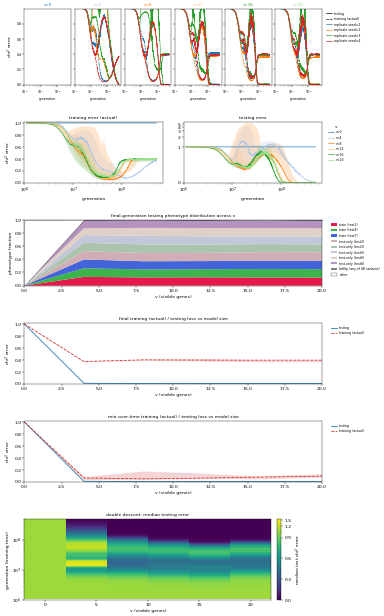
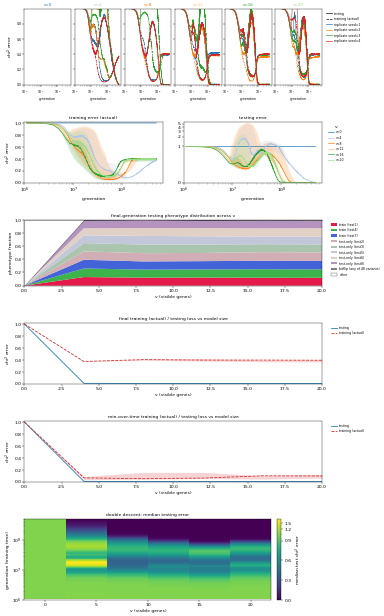
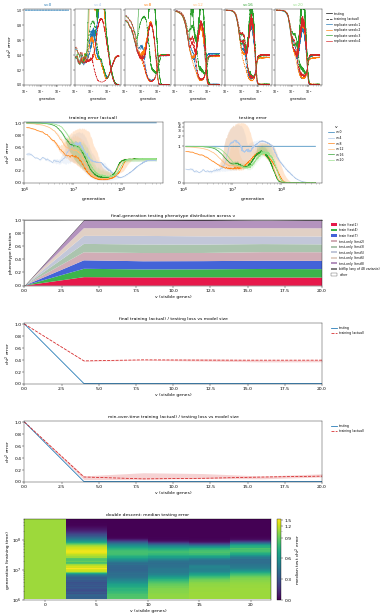
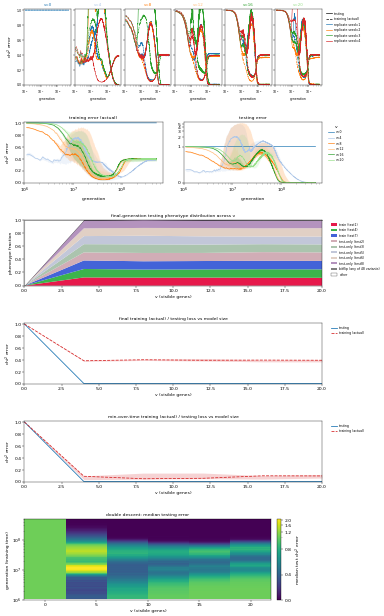
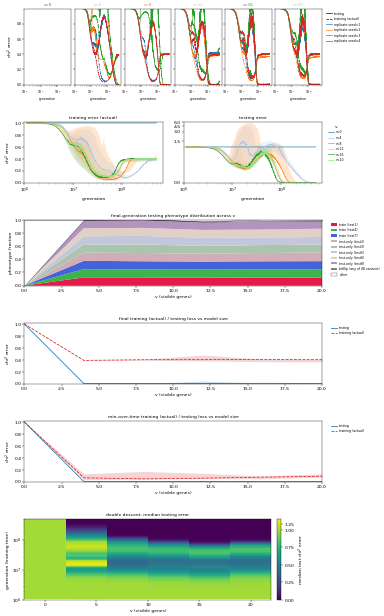
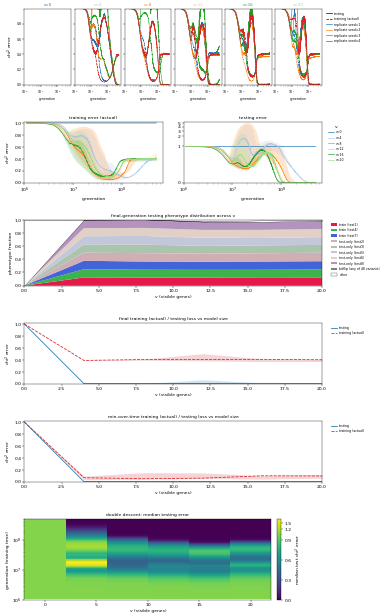
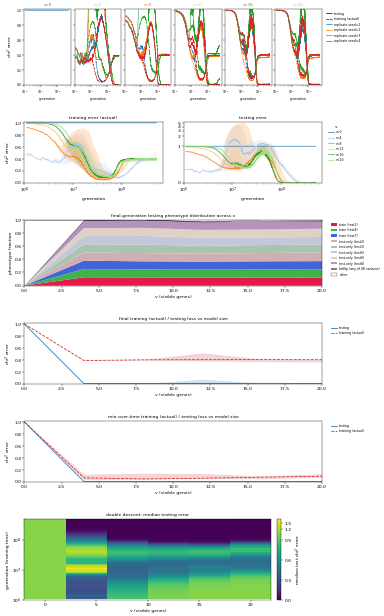
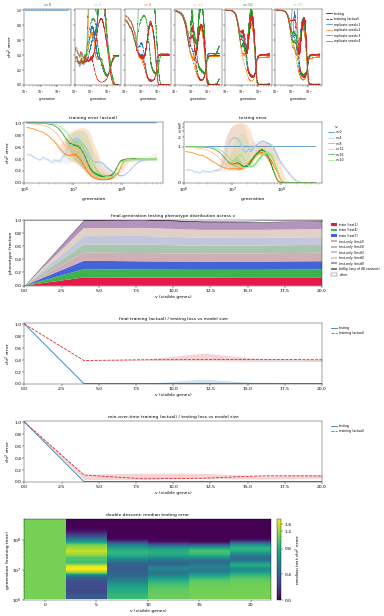
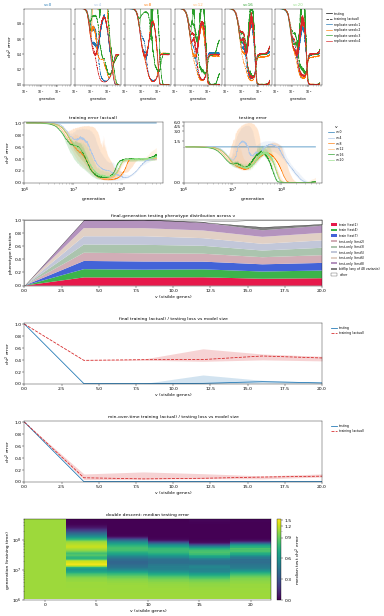
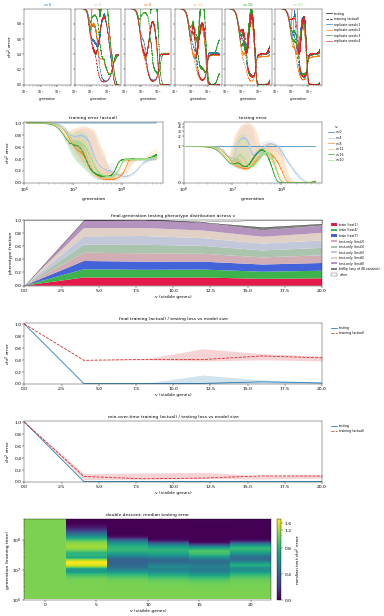
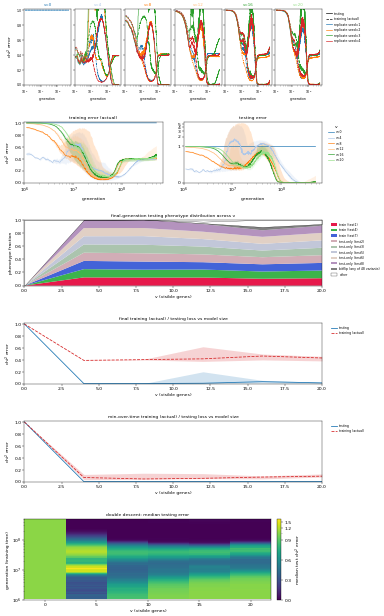
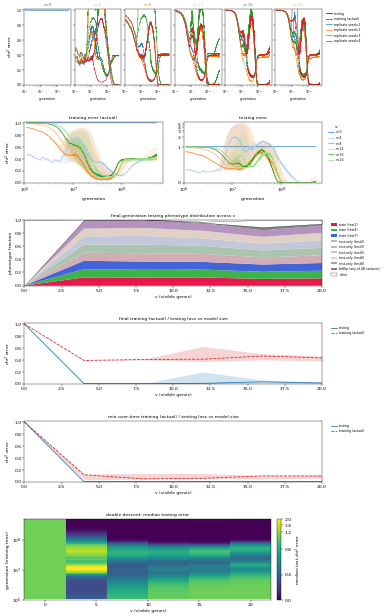
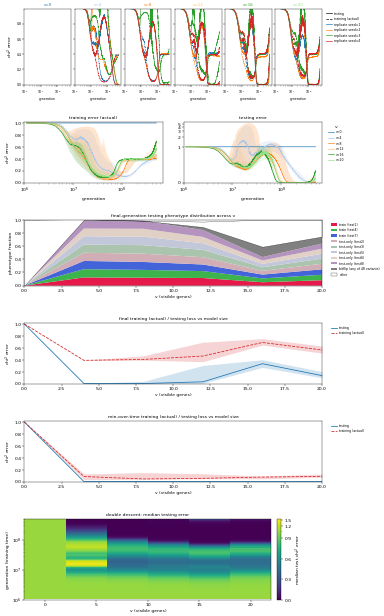
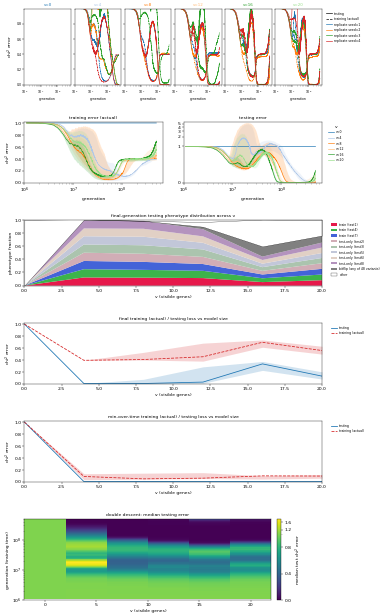
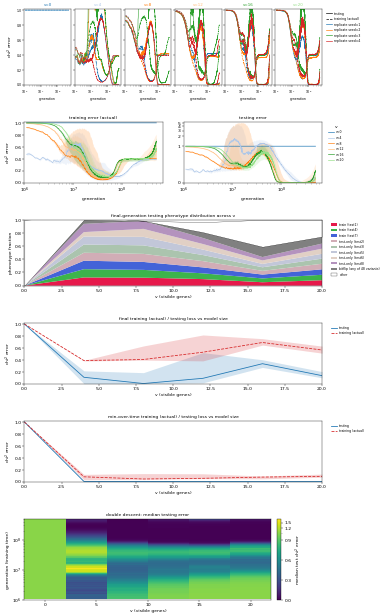
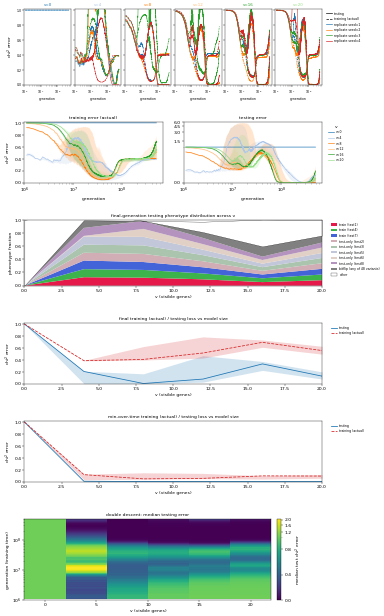
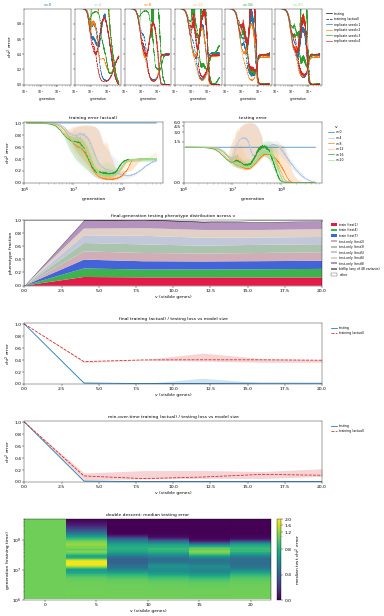
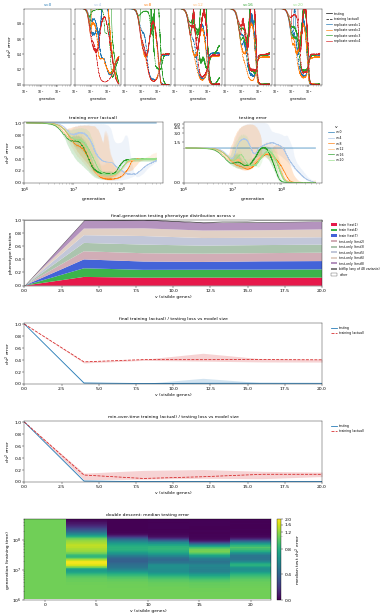
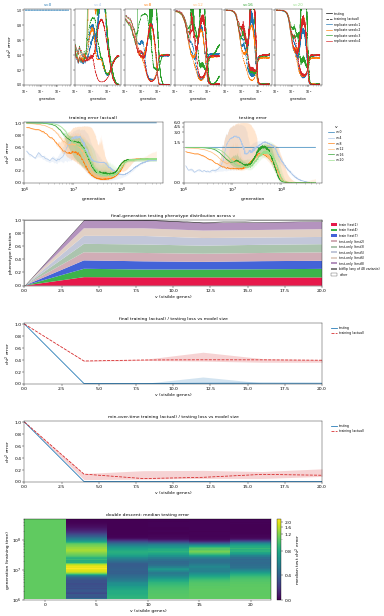
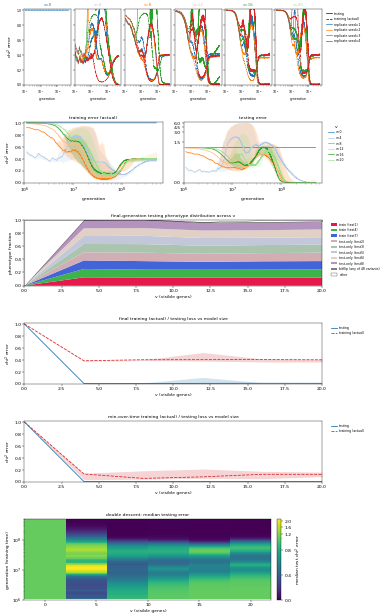
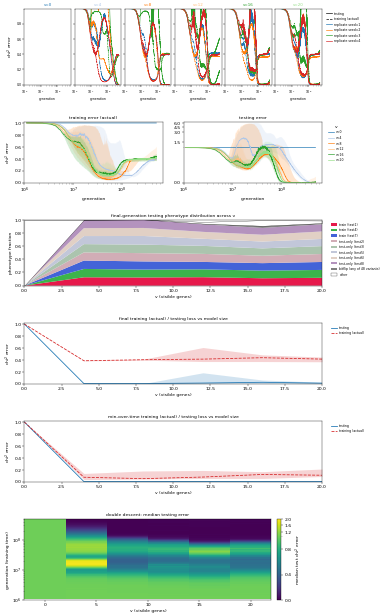
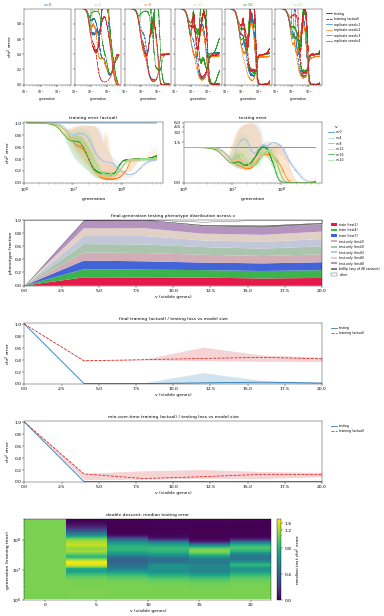
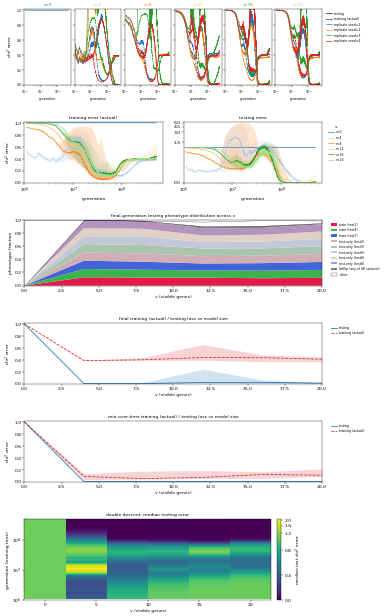
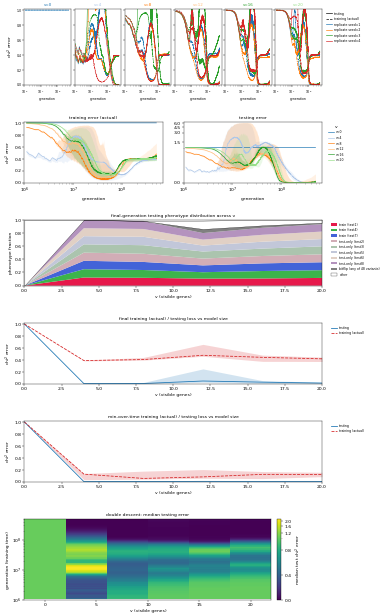
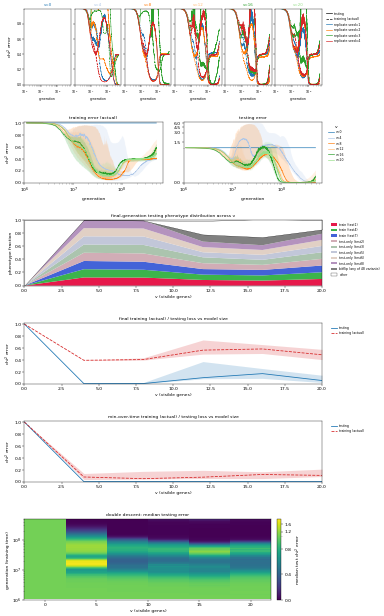
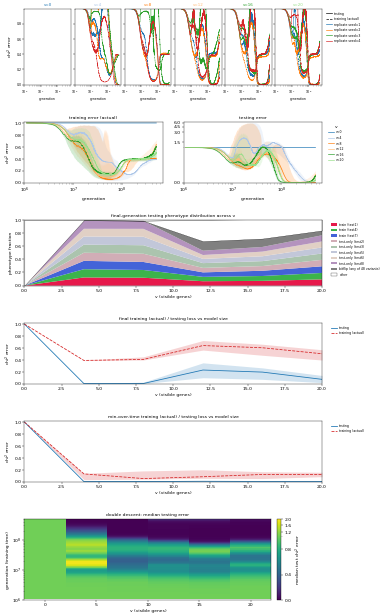
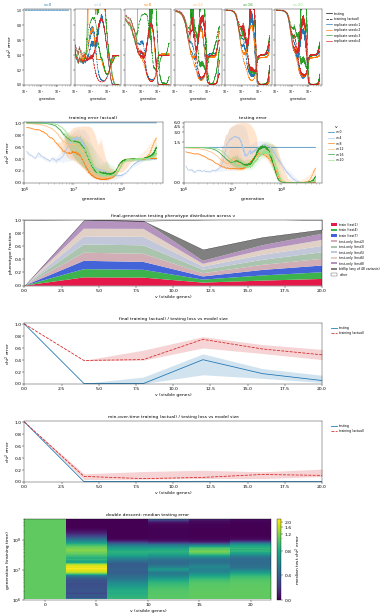
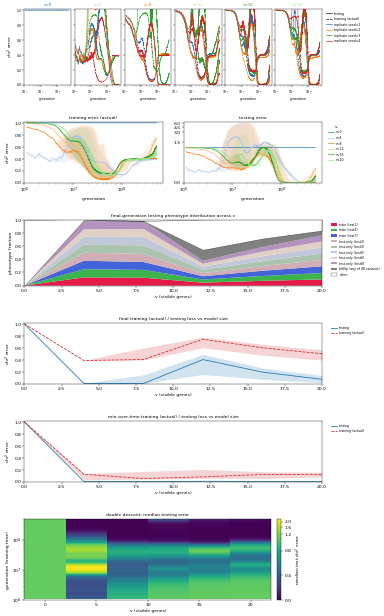
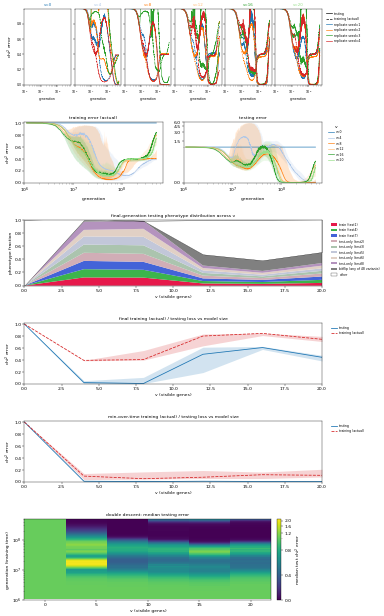
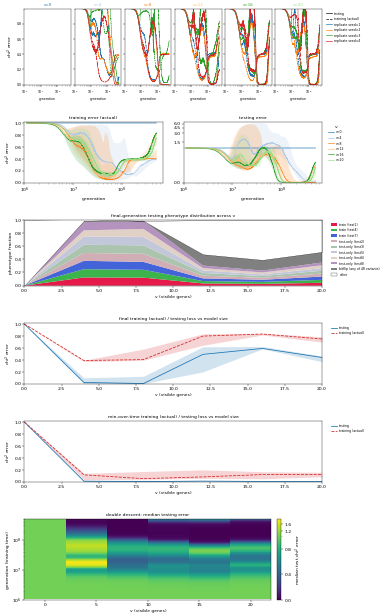
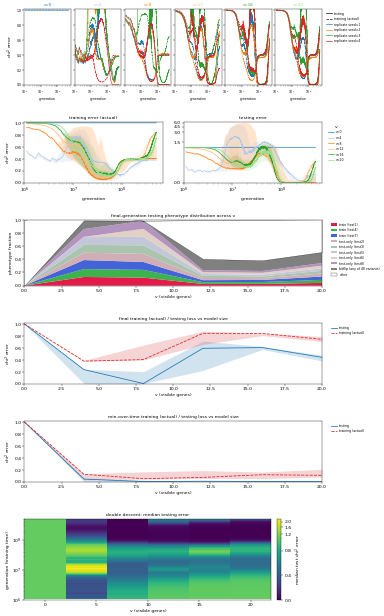
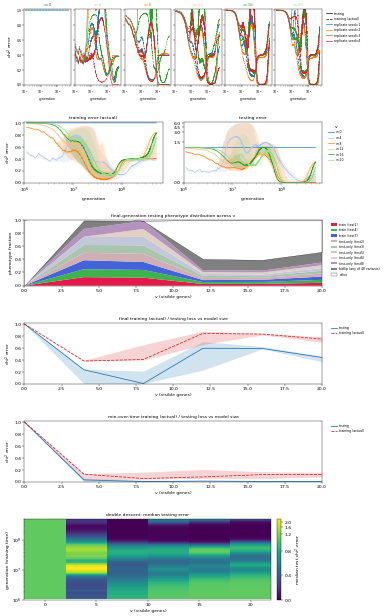
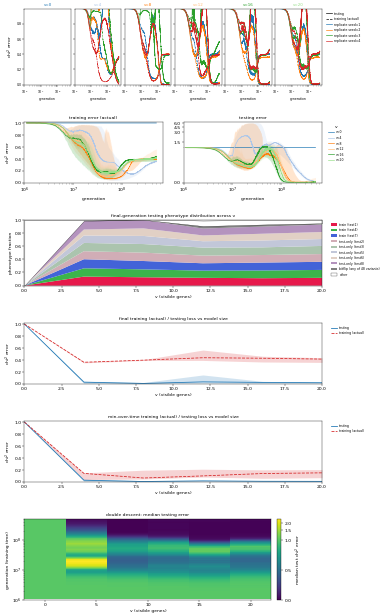
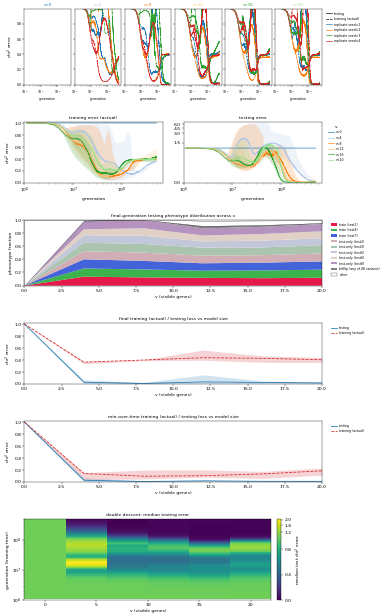
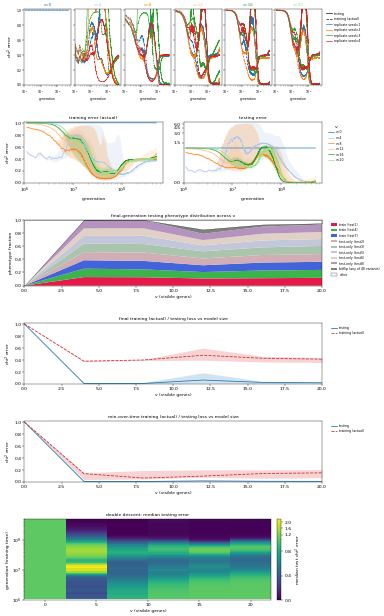
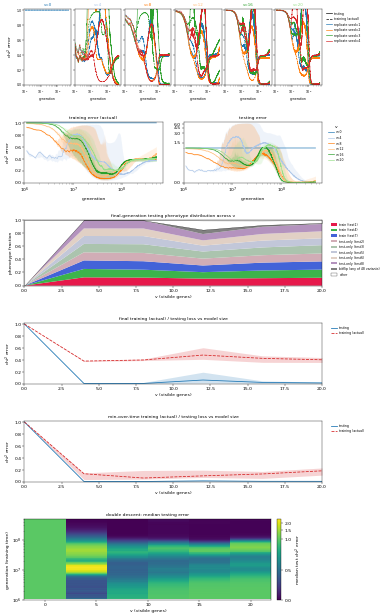
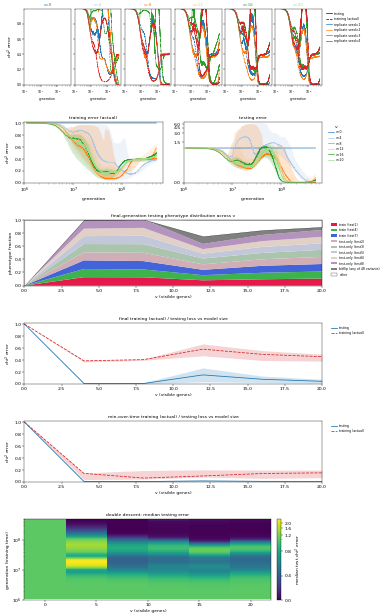
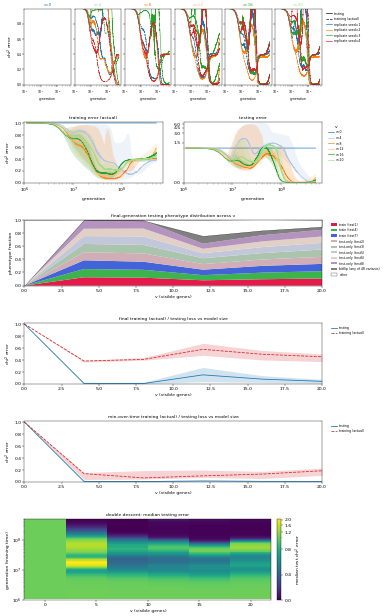
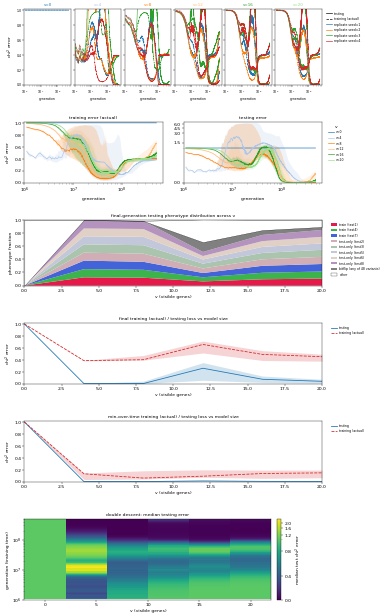
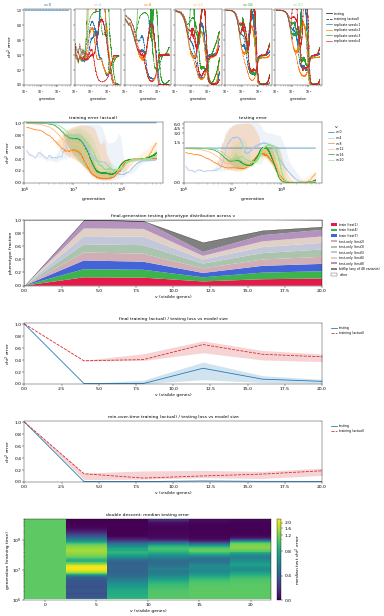
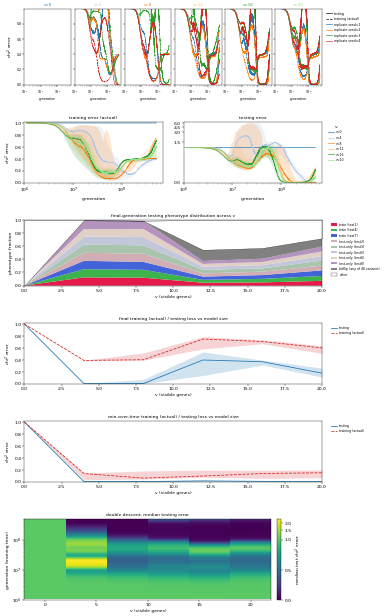
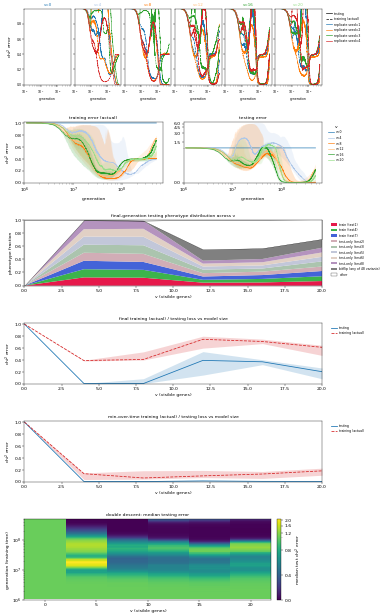
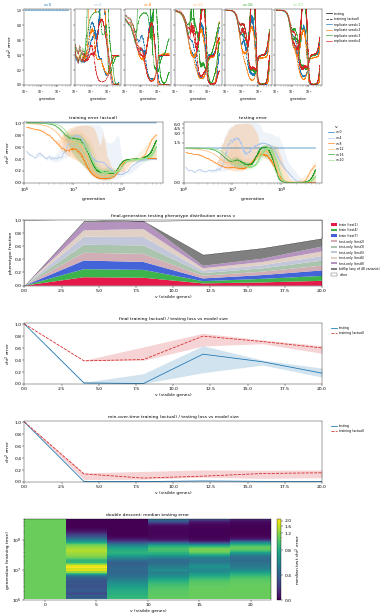
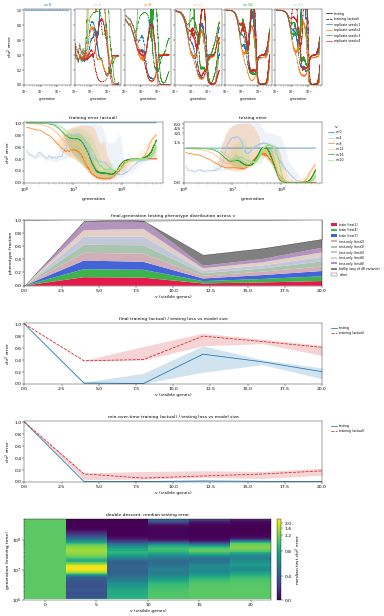
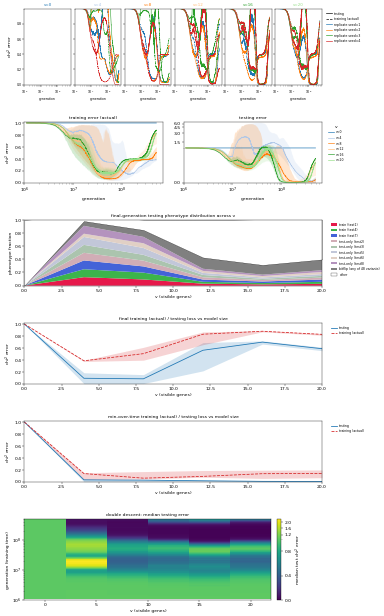
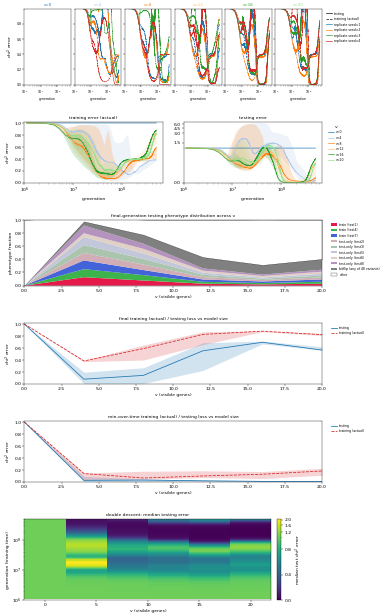
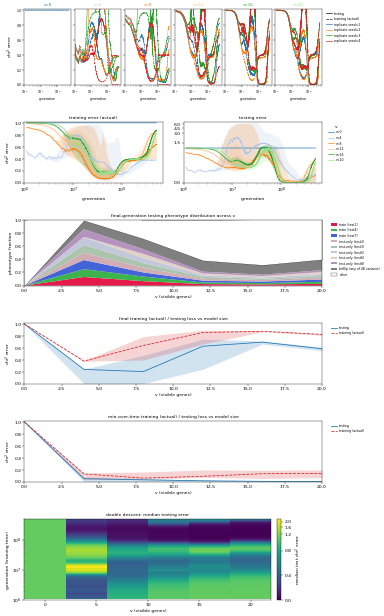
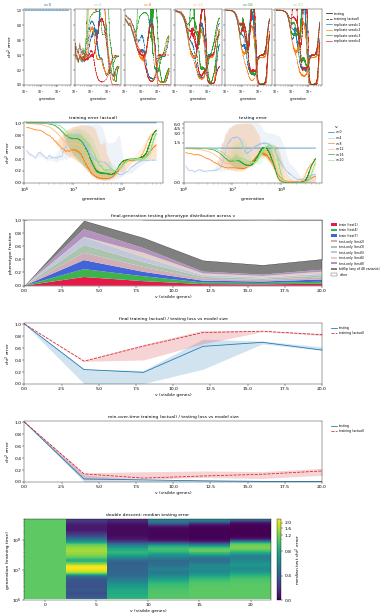
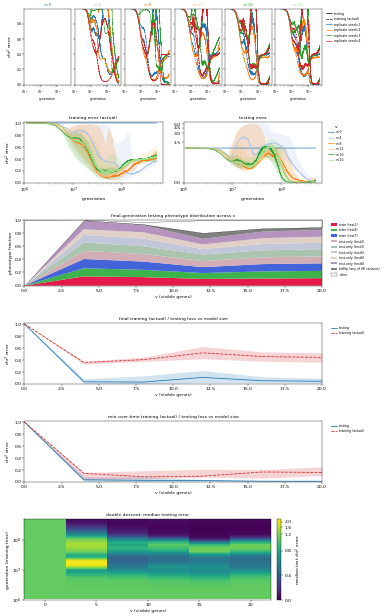
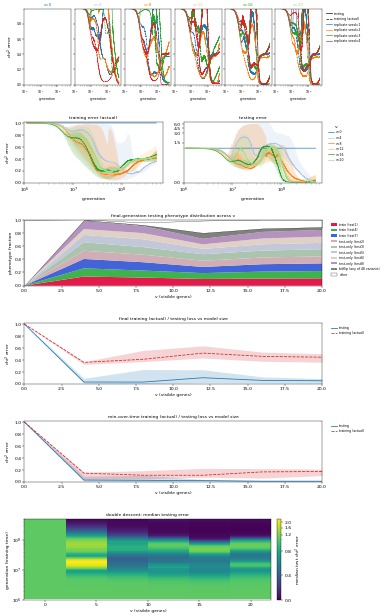
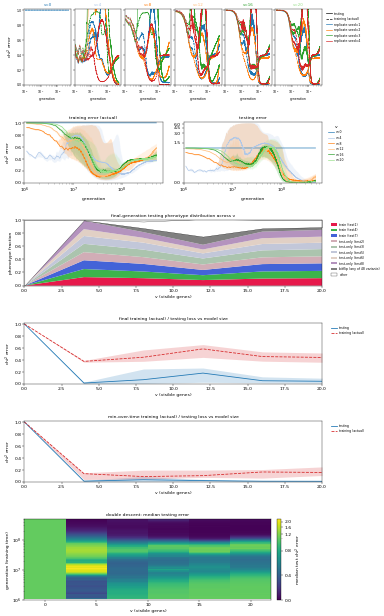
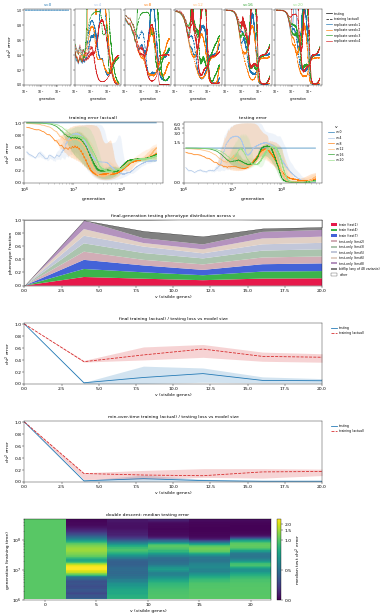
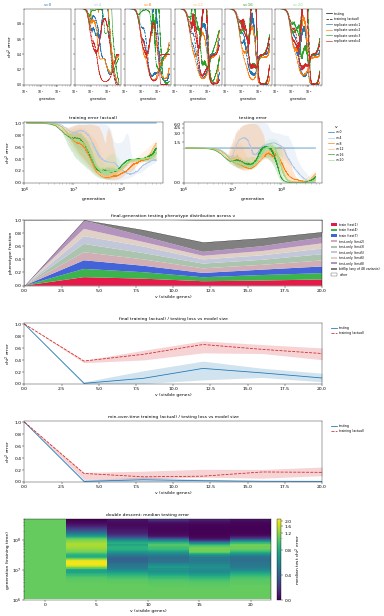
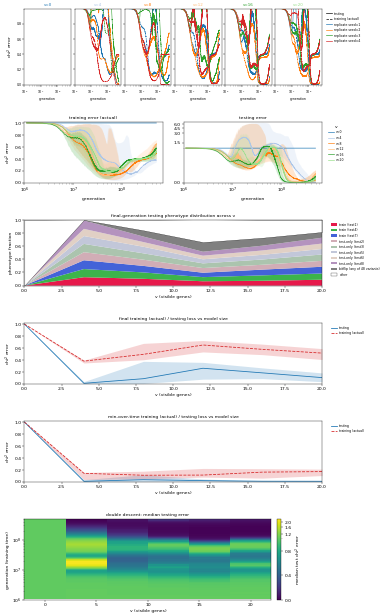
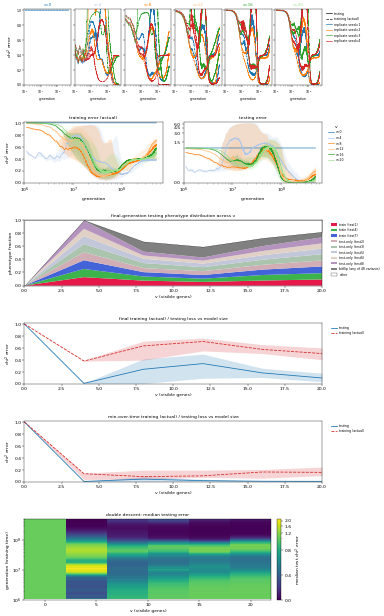
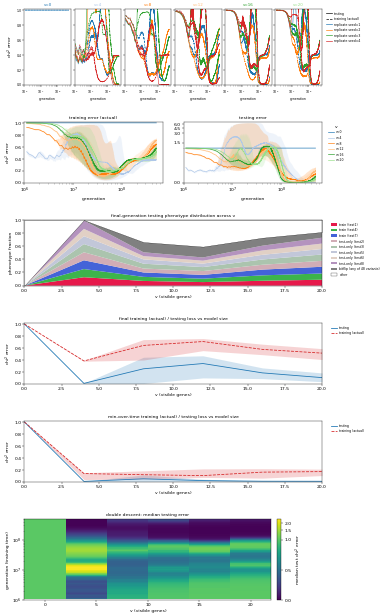
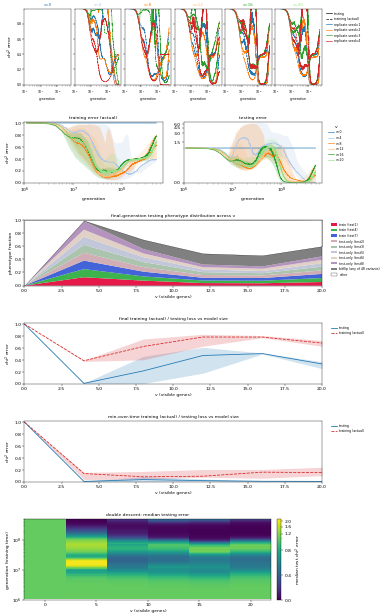
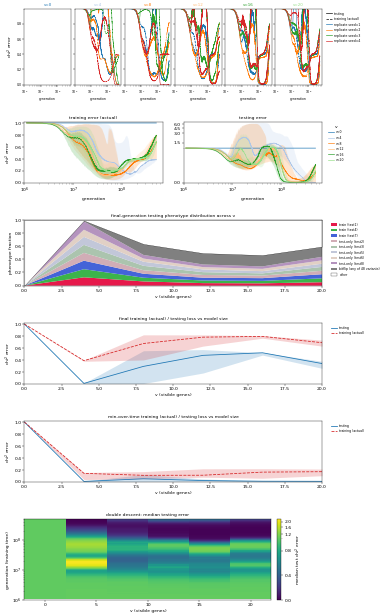
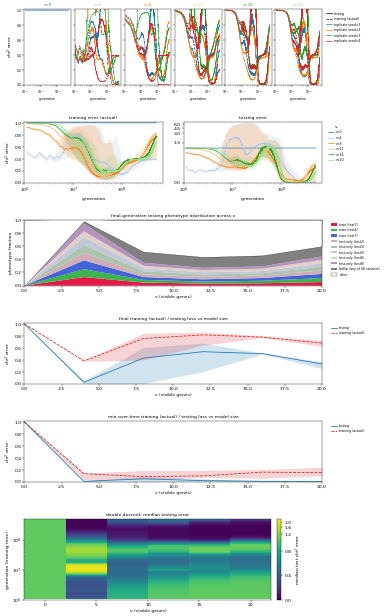
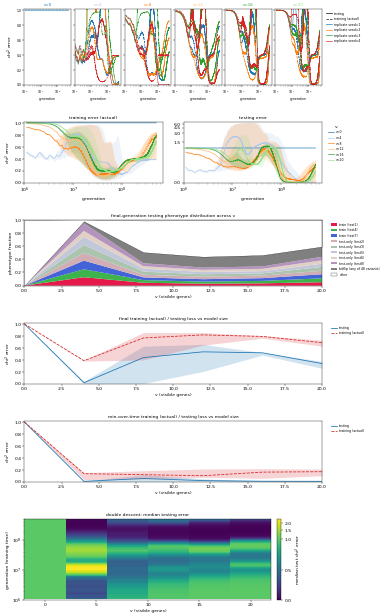
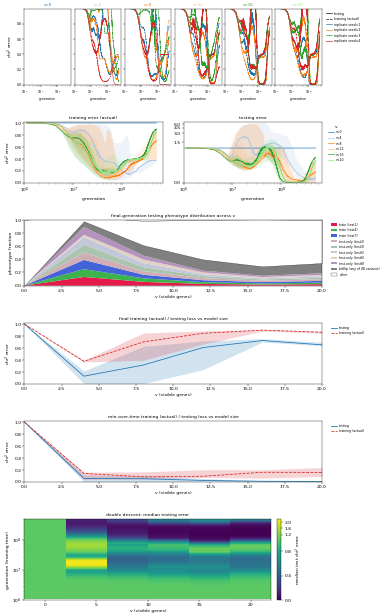
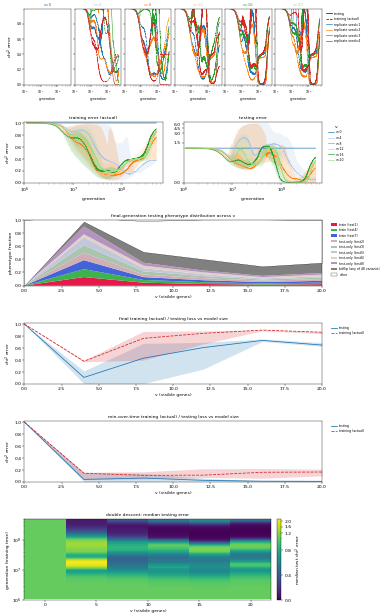
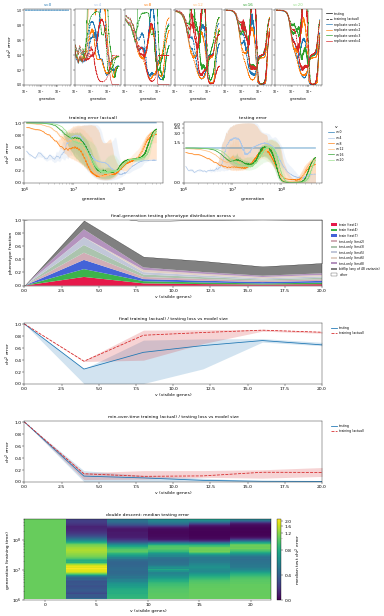
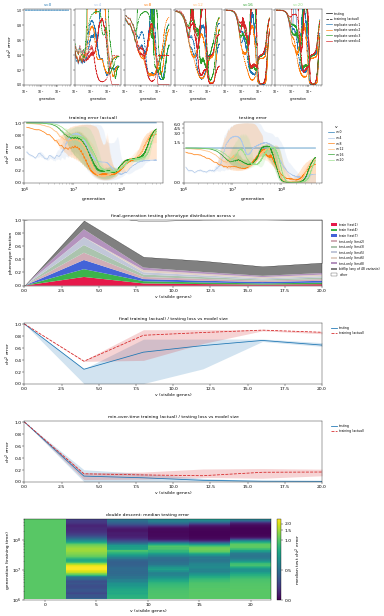

In [ ]:
for _, _cond in conditions.iterrows():
    _mask = np.logical_and.reduce(
        [df[c] == _cond[c] for c in CONDITION_COLS]
    )
    _df_cond = df[_mask]
    _n_replicates = _df_cond["seed"].nunique()

    # text spacer between compound plots (which are themselves
    # deliberately left untitled) identifying which condition follows.
    mo.output.append(
        mo.md(
            f"""
---
**dataset**=`{_cond['dataset']}`
&nbsp;**blip_freq**=`{_cond['blip_freq']}`
&nbsp;**l1_scale**=`{_cond['l1_scale']}`
&nbsp;**l2_scale**=`{_cond['l2_scale']}`
&nbsp;**zero_init**=`{_cond['zero_init']}`
&nbsp;**schedule_mode**=`{_cond['schedule_mode']}`
&nbsp;**n_replicates(seeds)/v**=`{_n_replicates}`
"""
        )
    )

    with tp.teed(
        make_compound_plot,
        _df_cond,
        v_palette,
        teeplot_outattrs={
            "dataset": str(_cond["dataset"]),
            "blipfreq": str(_cond["blip_freq"]),
            "l1scale": str(_cond["l1_scale"]),
            "l2scale": str(_cond["l2_scale"]),
            "zeroinit": str(_cond["zero_init"]),
            "schedulemode": str(_cond["schedule_mode"]),
        },
        teeplot_subdir=pathlib.Path(__file__).stem,
        teeplot_show=False,
    ) as _fig:
        pass

    # mo.output.append renders the figure into the cell's output
    # immediately, so it's safe (and, across ~dozens of conditions,
    # necessary to avoid unbounded memory growth) to close it right
    # after.
    mo.output.append(_fig)
    plt.close(_fig)